# Task 1: Import the data and describe the sample

In [1]:
import pandas as pd

df = pd.read_csv('Data_PCLab1_Stock.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

price_cols = df.columns.drop('Date')  # reused across the notebook

n_stocks = price_cols.drop('sp500').shape[0]
print(f"Number of stocks: {n_stocks}")

null_counts = df.isnull().sum()
print(f"Contains null values: {null_counts.sum() > 0}")
print(null_counts)

avg_sp500 = df['sp500'].mean()
print(f"Average market value of S&P500: {avg_sp500:.2f}")

dispersion = df[price_cols].std()
min_dispersion_col = dispersion.idxmin()
print(f"Minimum dispersion in dollar value: {min_dispersion_col} (std = {dispersion.min():.2f})")

max_amzn_price = df['AMZN'].max()
print(f"Maximum price for Amazon stock: {max_amzn_price:.2f}")


Number of stocks: 8
Contains null values: False
Date     0
AAPL     0
BA       0
T        0
MGM      0
AMZN     0
IBM      0
TSLA     0
GOOG     0
sp500    0
dtype: int64
Average market value of S&P500: 2218.75
Minimum dispersion in dollar value: T (std = 3.21)
Maximum price for Amazon stock: 3225.00


# Task 2: Plot the data

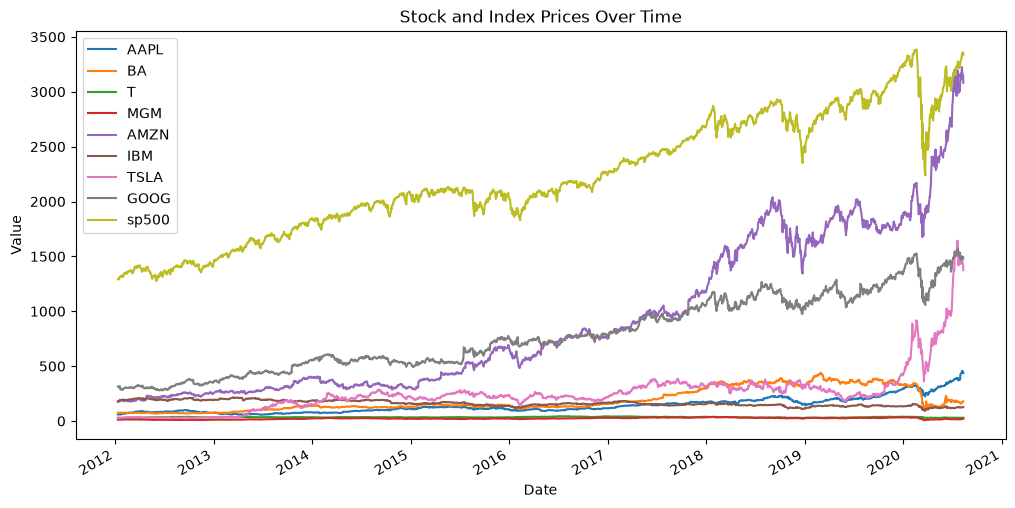

In [2]:
import matplotlib.pyplot as plt

def plot_dataframe(dataframe):
    dataframe.set_index('Date').plot(figsize=(12, 6))
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.title('Stock and Index Prices Over Time')
    plt.legend(loc='best')
    plt.show()

plot_dataframe(df)


# Task 3: Print normalized (scaled) stock prices

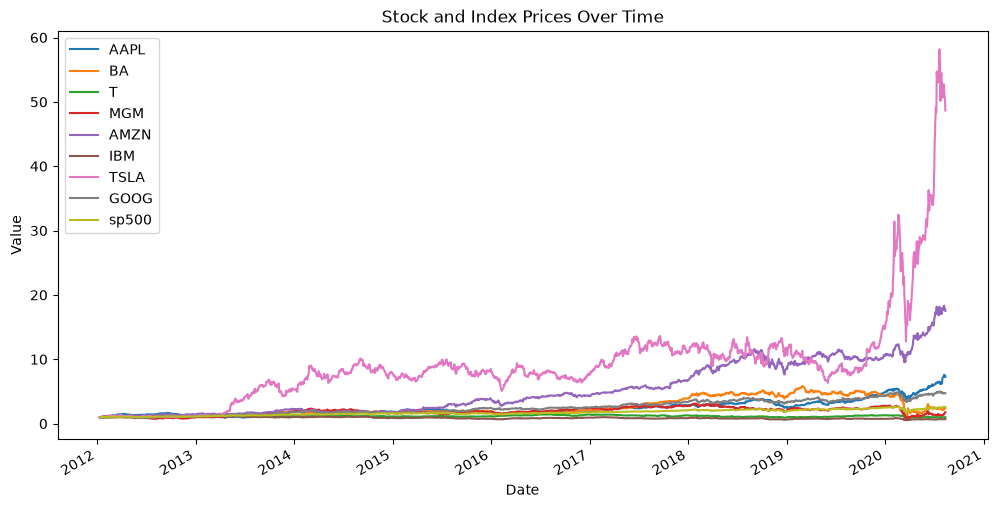

In [3]:
def normalize_prices(dataframe):
    normalized = dataframe.copy() # Not mutate original df
    initial_prices = normalized.loc[normalized['Date'] == '2012-01-12', price_cols].iloc[0] # Pick first date row
    normalized[price_cols] = normalized[price_cols] / initial_prices
    return normalized

df_normalized = normalize_prices(df)
plot_dataframe(df_normalized)


# Task 5 (who needs 4): Calculate stock returns

### Daily returns

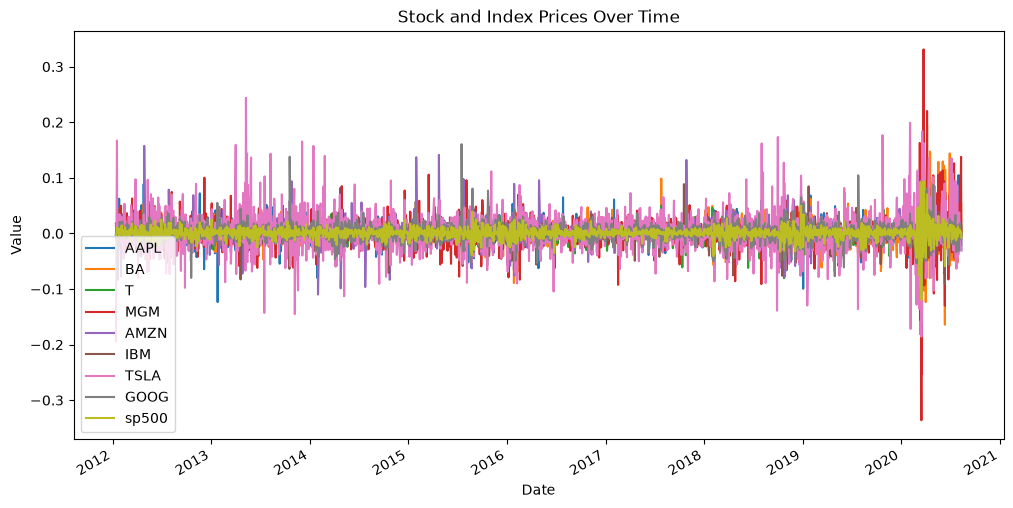

In [4]:
def daily_returns(dataframe):
    returns = dataframe.copy()

    for stock in price_cols:
        prices = returns[stock].tolist()
        daily_returns = [None]  # no return on the first day
        for day_index in range(1, len(prices)):
            yesterday_price = prices[day_index - 1]
            today_price = prices[day_index]
            daily_return = (today_price - yesterday_price) / yesterday_price
            daily_returns.append(daily_return)
        returns[stock] = daily_returns

    return returns

df_returns = daily_returns(df)
plot_dataframe(df_returns)


### Correlations

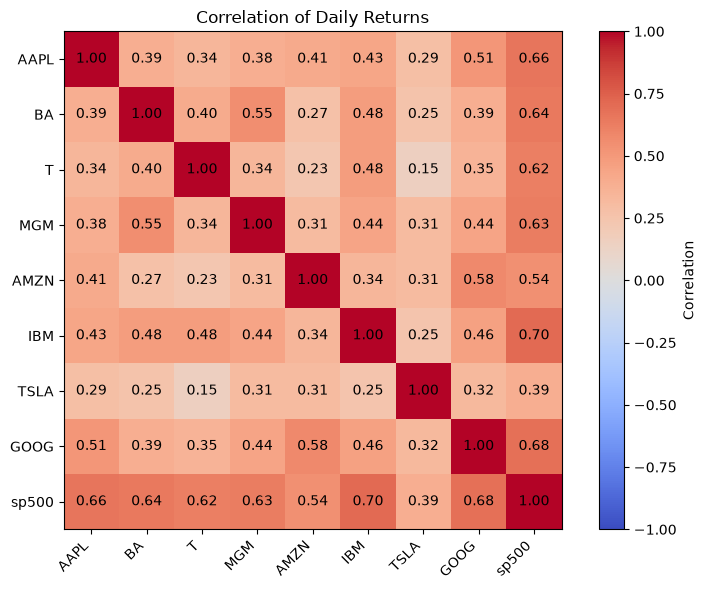

In [5]:
import numpy as np

corr_matrix = df_returns[price_cols].corr()  # Calculate correlation matix

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1) # Heatmap

ax.set_xticks(range(len(price_cols)))
ax.set_yticks(range(len(price_cols)))
ax.set_xticklabels(price_cols, rotation=45, ha='right')
ax.set_yticklabels(price_cols)

for i in range(len(price_cols)):
    for j in range(len(price_cols)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha='center', va='center', color='black') # Label each cell with it's correlation

fig.colorbar(im, ax=ax, label='Correlation')
ax.set_title('Correlation of Daily Returns')
plt.tight_layout()
plt.show()


> 
> The top two stocks that are positively correlated with s&p 500 are IBM and Alphabet (GOOG), with respective correlations of 0.7 and 0.68
> 
> Amazon (AMZN) and Boeing (BA) have a correlation of 0.27. Quite low, which makes sense as these firms operate in different industries. Stocks in similar industries tend to be more correlated, e.g. Apple, Alphabet, Amazon and IBM show higher correlation.
>
> MGM and Boeing (BA) has a correlation of 0.55, this could again be because of them both operating in travel business, and factors such as the Covid-19 pandemic could have similar effects on these.
>

### Histograms

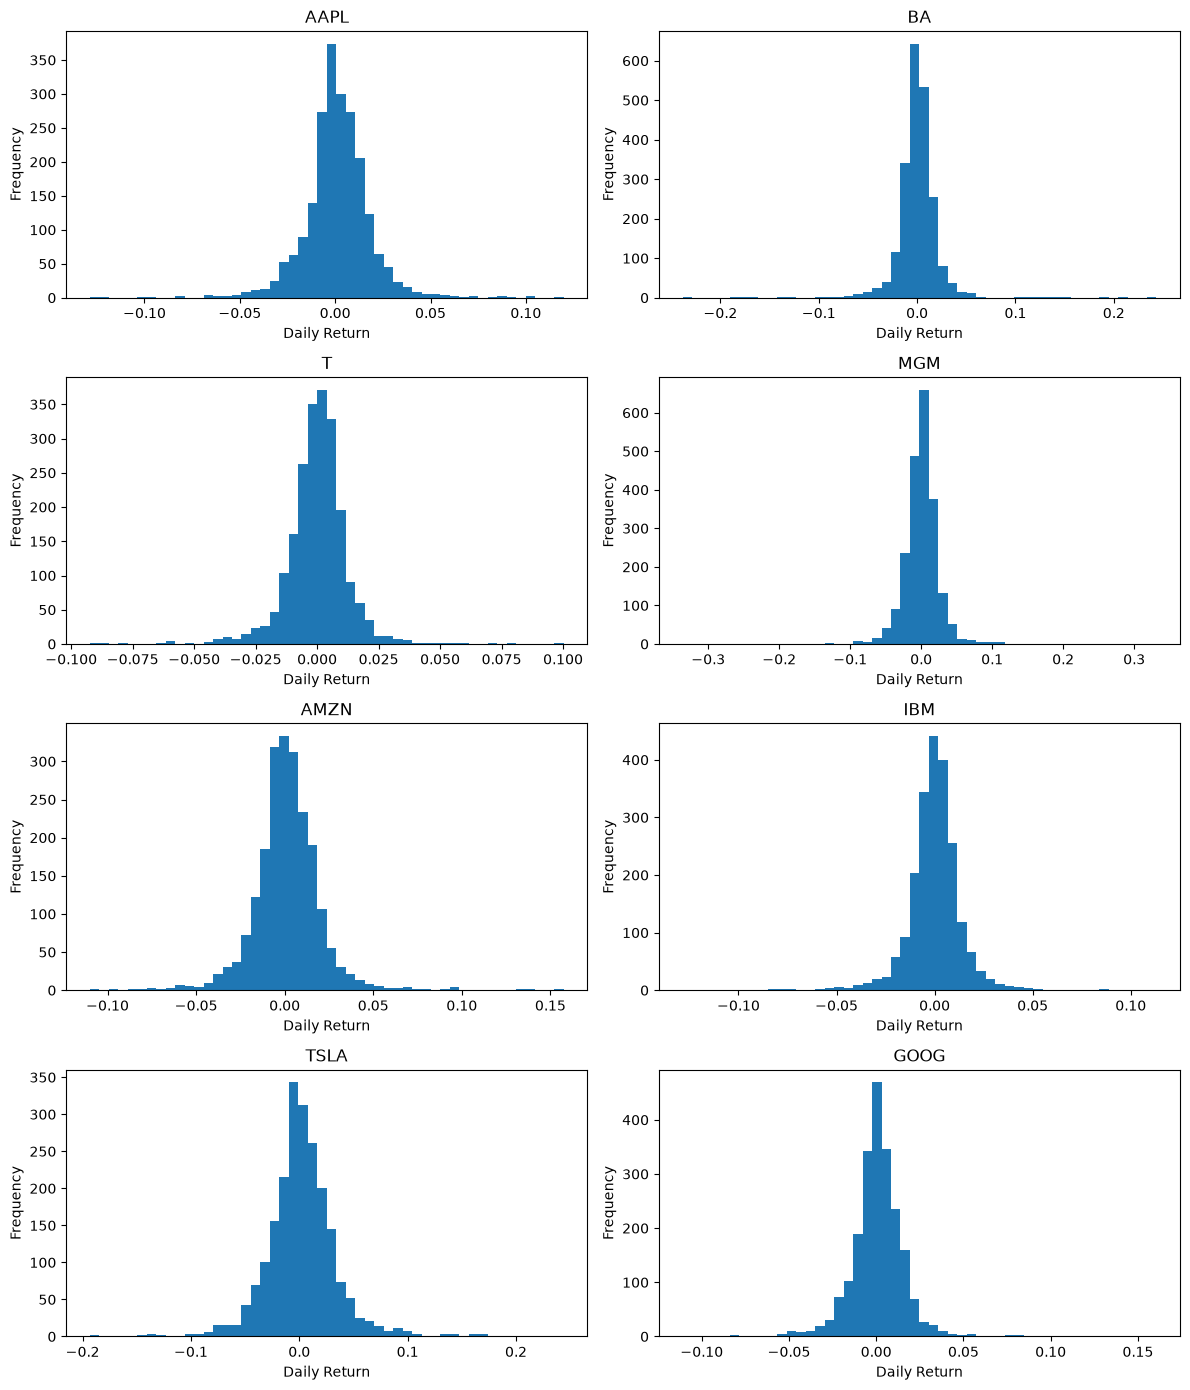

In [6]:
fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes = axes.flatten()

for ax, stock in zip(axes, price_cols):
    ax.hist(df_returns[stock].dropna(), bins=50)
    ax.set_title(stock)
    ax.set_xlabel('Daily Return')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()


In [7]:
import plotly.figure_factory as ff

def plot_interactive_histograms(dataframe):
    hist_data = [dataframe[stock].dropna() for stock in price_cols]

    fig = ff.create_distplot(hist_data, group_labels=list(price_cols), bin_size=0.01)
    fig.update_layout(title='Distribution of Daily Returns', xaxis_title='Daily Return', yaxis_title='Density')
    fig.show()

plot_interactive_histograms(df_returns)
